# Lecture 10 - Exercises: Estimating pi with the volume of iperspheres, Markov Chain introduction


In [77]:
#######################
### L10 - Exercises ###
#######################

In [78]:
# importing libraries and setting up nice plots

import os
import numpy                        as     np
import matplotlib.pyplot            as     plt
from   matplotlib                   import rc
from   sys                          import stdout
from   scipy                        import special

from   scipy                        import stats, integrate
from   astroML                      import stats as astroMLstats
from   astropy.visualization.hist   import hist as fancyhist
from   sklearn.neighbors            import KernelDensity


plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif" : ["Times New Roman"],
	"font.size"  : 9,
    "figure.dpi" : 300
    })
plt.rc('text.latex', preamble=r'\usepackage{amssymb}')

# did we start this notebook from ".../GitHub/working" directory or from ".../GitHub" (by accident)?
current_pwd = os.getcwd()
print(current_pwd)

D:\Documents\University\Magistrale\Statistics\GitHub\working


# Exercise 01 - Volume of iperspheres, and how to use it to estimate $\pi$

In [79]:
#-------------------------------------------------------------------------
# # uniformly extract M random vectors of dimension N. 
# Count how many are in the N-sphere, for different values of N. 
M = 100000
N = range(2,31)
# previously = [2,3,4,5,6,7,8,9,10,20,30,40,50,100,1000]

# here I use a list instead of a numpy array because
### x[i] will be an array containing M vectors of different size n = N[i]
### x[1] = [ [] , [] , ... , Mtimes, ... , [] ]
### x[1][0] = [ a, b, c]
x = []
for n in N:
    x.append(stats.uniform(-1,1).rvs((M,n)))

#-------------------------------------------------------------------------
# define the L2 radius of an n-vector

def radius(x):
    r2 = 0.
    for x_m_n in x:
        r2 += x_m_n**2
    return np.sqrt(r2)

#-------------------------------------------------------------------------
# compute the radii - now we can use numpy because the array has fixed len in both directions

r = np.zeros((len(N),M))
for m in range(M):
    for i, n in enumerate(N):
        r[i,m] = radius(x[i][m])

# count the extracted vectors within the surface delimited by the hypersphere
counts = np.zeros(len(N))
for m in range(M):
    for i in range(len(N)):
        if r[i,m] < 1:
            counts[i] += 1

#-------------------------------------------------------------------------
# print results for the volumes and for the estimates of pi (and its errors)

for n, c in zip(N,counts):
    printstring = 'In {:d}D, V_sphere / V_cube = {:.3e}  ;  V_sphere = {:.3e}'.format(n, c/M, c/M * 2**n)
    if n==2:
        pi = c/M *4
        er = (np.pi-pi)/np.pi
        printstring += '  ;  pi_exp. = {:3f}  ;  err% = {:.3%}'.format(pi,er)
    elif n==3:
        pi = c/M *8*3/4
        er = (np.pi-pi)/np.pi
        printstring += '  ;  pi_exp. = {:3f}  ;  err% = {:.3%}'.format(pi,er)
    print(printstring)


#-------------------------------------------------------------------------
# explanation because I'm dumb and I keep forgetting factors

# for "hyperspheres" satisfying: r^2 = sum_i^n x_i^2 ; 
# for "hypercubes" they're inscribed within

# in 2D, A_circle = pi * r^2 ; A_square = (2r)^2 = 4 r^2
# =====> pi = A_circle / r^2 = A_circle / A_square * 2^2 

# in 3D, V_sphere = pi * r^3 * 4/3 ; V_cube   = (2r)^3
# =====> pi = V_sphere * 3/4 / r^3 = V_sphere / V_cube * 2^3 * 3/4

# in ND, V_hypersphere / V_hypercube = (#points with r < 1) / (#points) 

In 2D, V_sphere / V_cube = 7.863e-01  ;  V_sphere = 3.145e+00  ;  pi_exp. = 3.145040  ;  err% = -0.110%
In 3D, V_sphere / V_cube = 5.229e-01  ;  V_sphere = 4.183e+00  ;  pi_exp. = 3.137340  ;  err% = 0.135%
In 4D, V_sphere / V_cube = 3.070e-01  ;  V_sphere = 4.911e+00
In 5D, V_sphere / V_cube = 1.659e-01  ;  V_sphere = 5.308e+00
In 6D, V_sphere / V_cube = 8.006e-02  ;  V_sphere = 5.124e+00
In 7D, V_sphere / V_cube = 3.738e-02  ;  V_sphere = 4.785e+00
In 8D, V_sphere / V_cube = 1.632e-02  ;  V_sphere = 4.178e+00
In 9D, V_sphere / V_cube = 6.800e-03  ;  V_sphere = 3.482e+00
In 10D, V_sphere / V_cube = 2.430e-03  ;  V_sphere = 2.488e+00
In 11D, V_sphere / V_cube = 7.600e-04  ;  V_sphere = 1.556e+00
In 12D, V_sphere / V_cube = 3.300e-04  ;  V_sphere = 1.352e+00
In 13D, V_sphere / V_cube = 8.000e-05  ;  V_sphere = 6.554e-01
In 14D, V_sphere / V_cube = 5.000e-05  ;  V_sphere = 8.192e-01
In 15D, V_sphere / V_cube = 1.000e-05  ;  V_sphere = 3.277e-01
In 16D, V_sphere / V_cube = 0.000e+00  ;  V

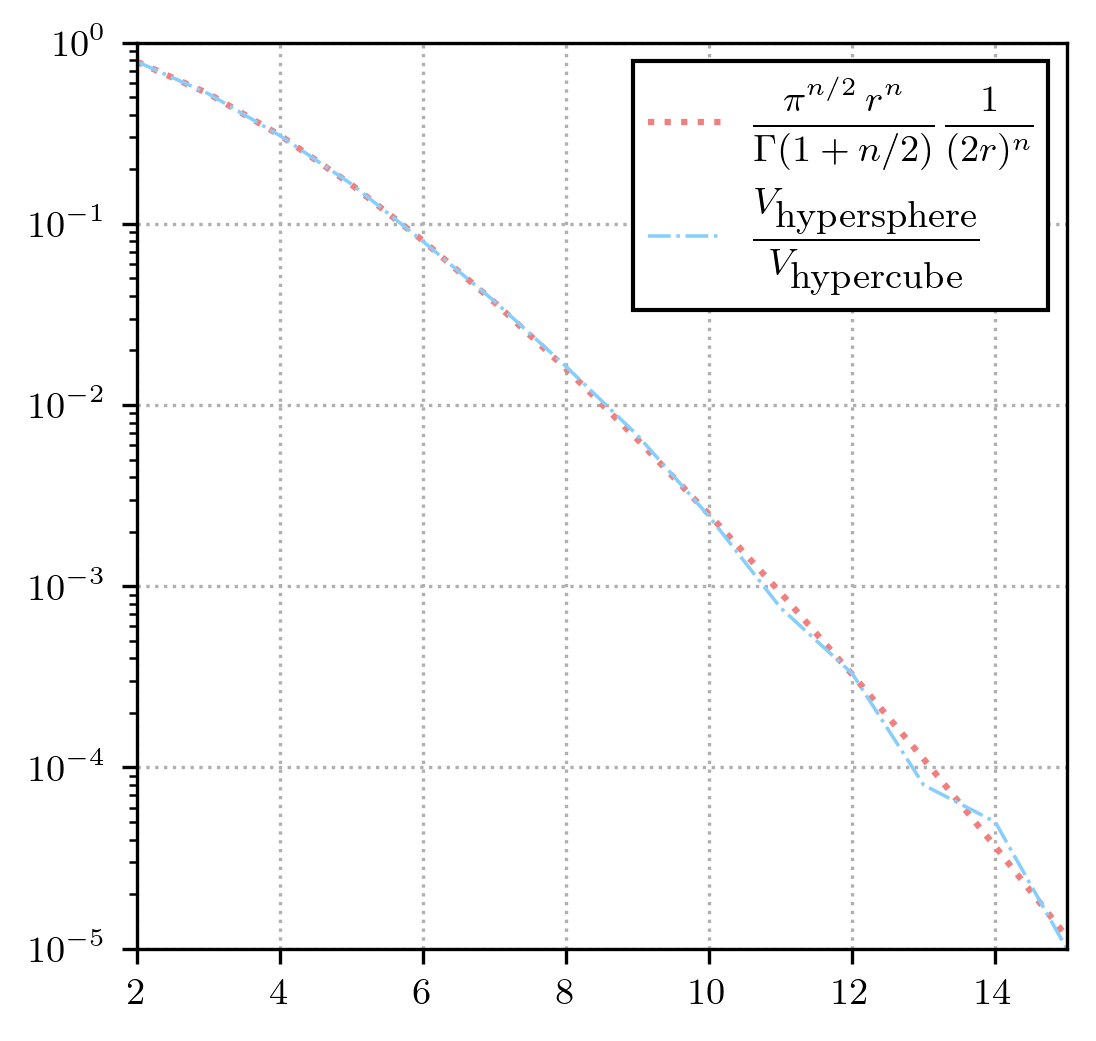

In [80]:
#-------------------------------------------------------------------------
# theoretical prediction of the volume of the hypersphere

def Volume_ipersphere(n,r):
    return np.pi**(n/2) / special.gamma(1+n/2) * r**n / ((2*r)**n)

fig , ax = plt.subplots(figsize=(4,4))

labeltheory= r'${ \displaystyle \frac{\pi^{n/2} \, r^n}{ \Gamma(1+n/2) }  \frac{1}{(2r)^n} } $' # \frac{V_{\textup{hypersphere}}}{V_{\textup{hypercube}}} = 

enne = np.array(N)
_ = ax.plot(enne, Volume_ipersphere(enne,1), color='lightcoral', ls=':', label=labeltheory)

labellissima = r'${ \displaystyle \frac{V_{\textup{hypersphere}}}{V_{\textup{hypercube}}} }$'

ax.set_xlim(2,15)
ax.set_ylim(1e-5,1)
ax.set_yscale('log')
ax.grid(ls=':')

_ = ax.plot(N,counts/M, color='lightskyblue', ls='-.', lw=0.85, label=labellissima)

_ = ax.legend(loc=1,frameon=True, framealpha=1, fancybox=False, edgecolor='black')

#-------------------------------------------------------------------------
# do we want to save the figure?
if True:
    if current_pwd[-6:] == 'GitHub':
        fig.savefig('./working/L10_images/L10_Volume_Hypersphere.pdf', bbox_inches='tight')
    elif current_pwd[-14:] == 'GitHub\working':
        fig.savefig('./L10_images/L10_Volume_Hypersphere.pdf', bbox_inches='tight')


# Exercise 02 - Weather Markov Chain

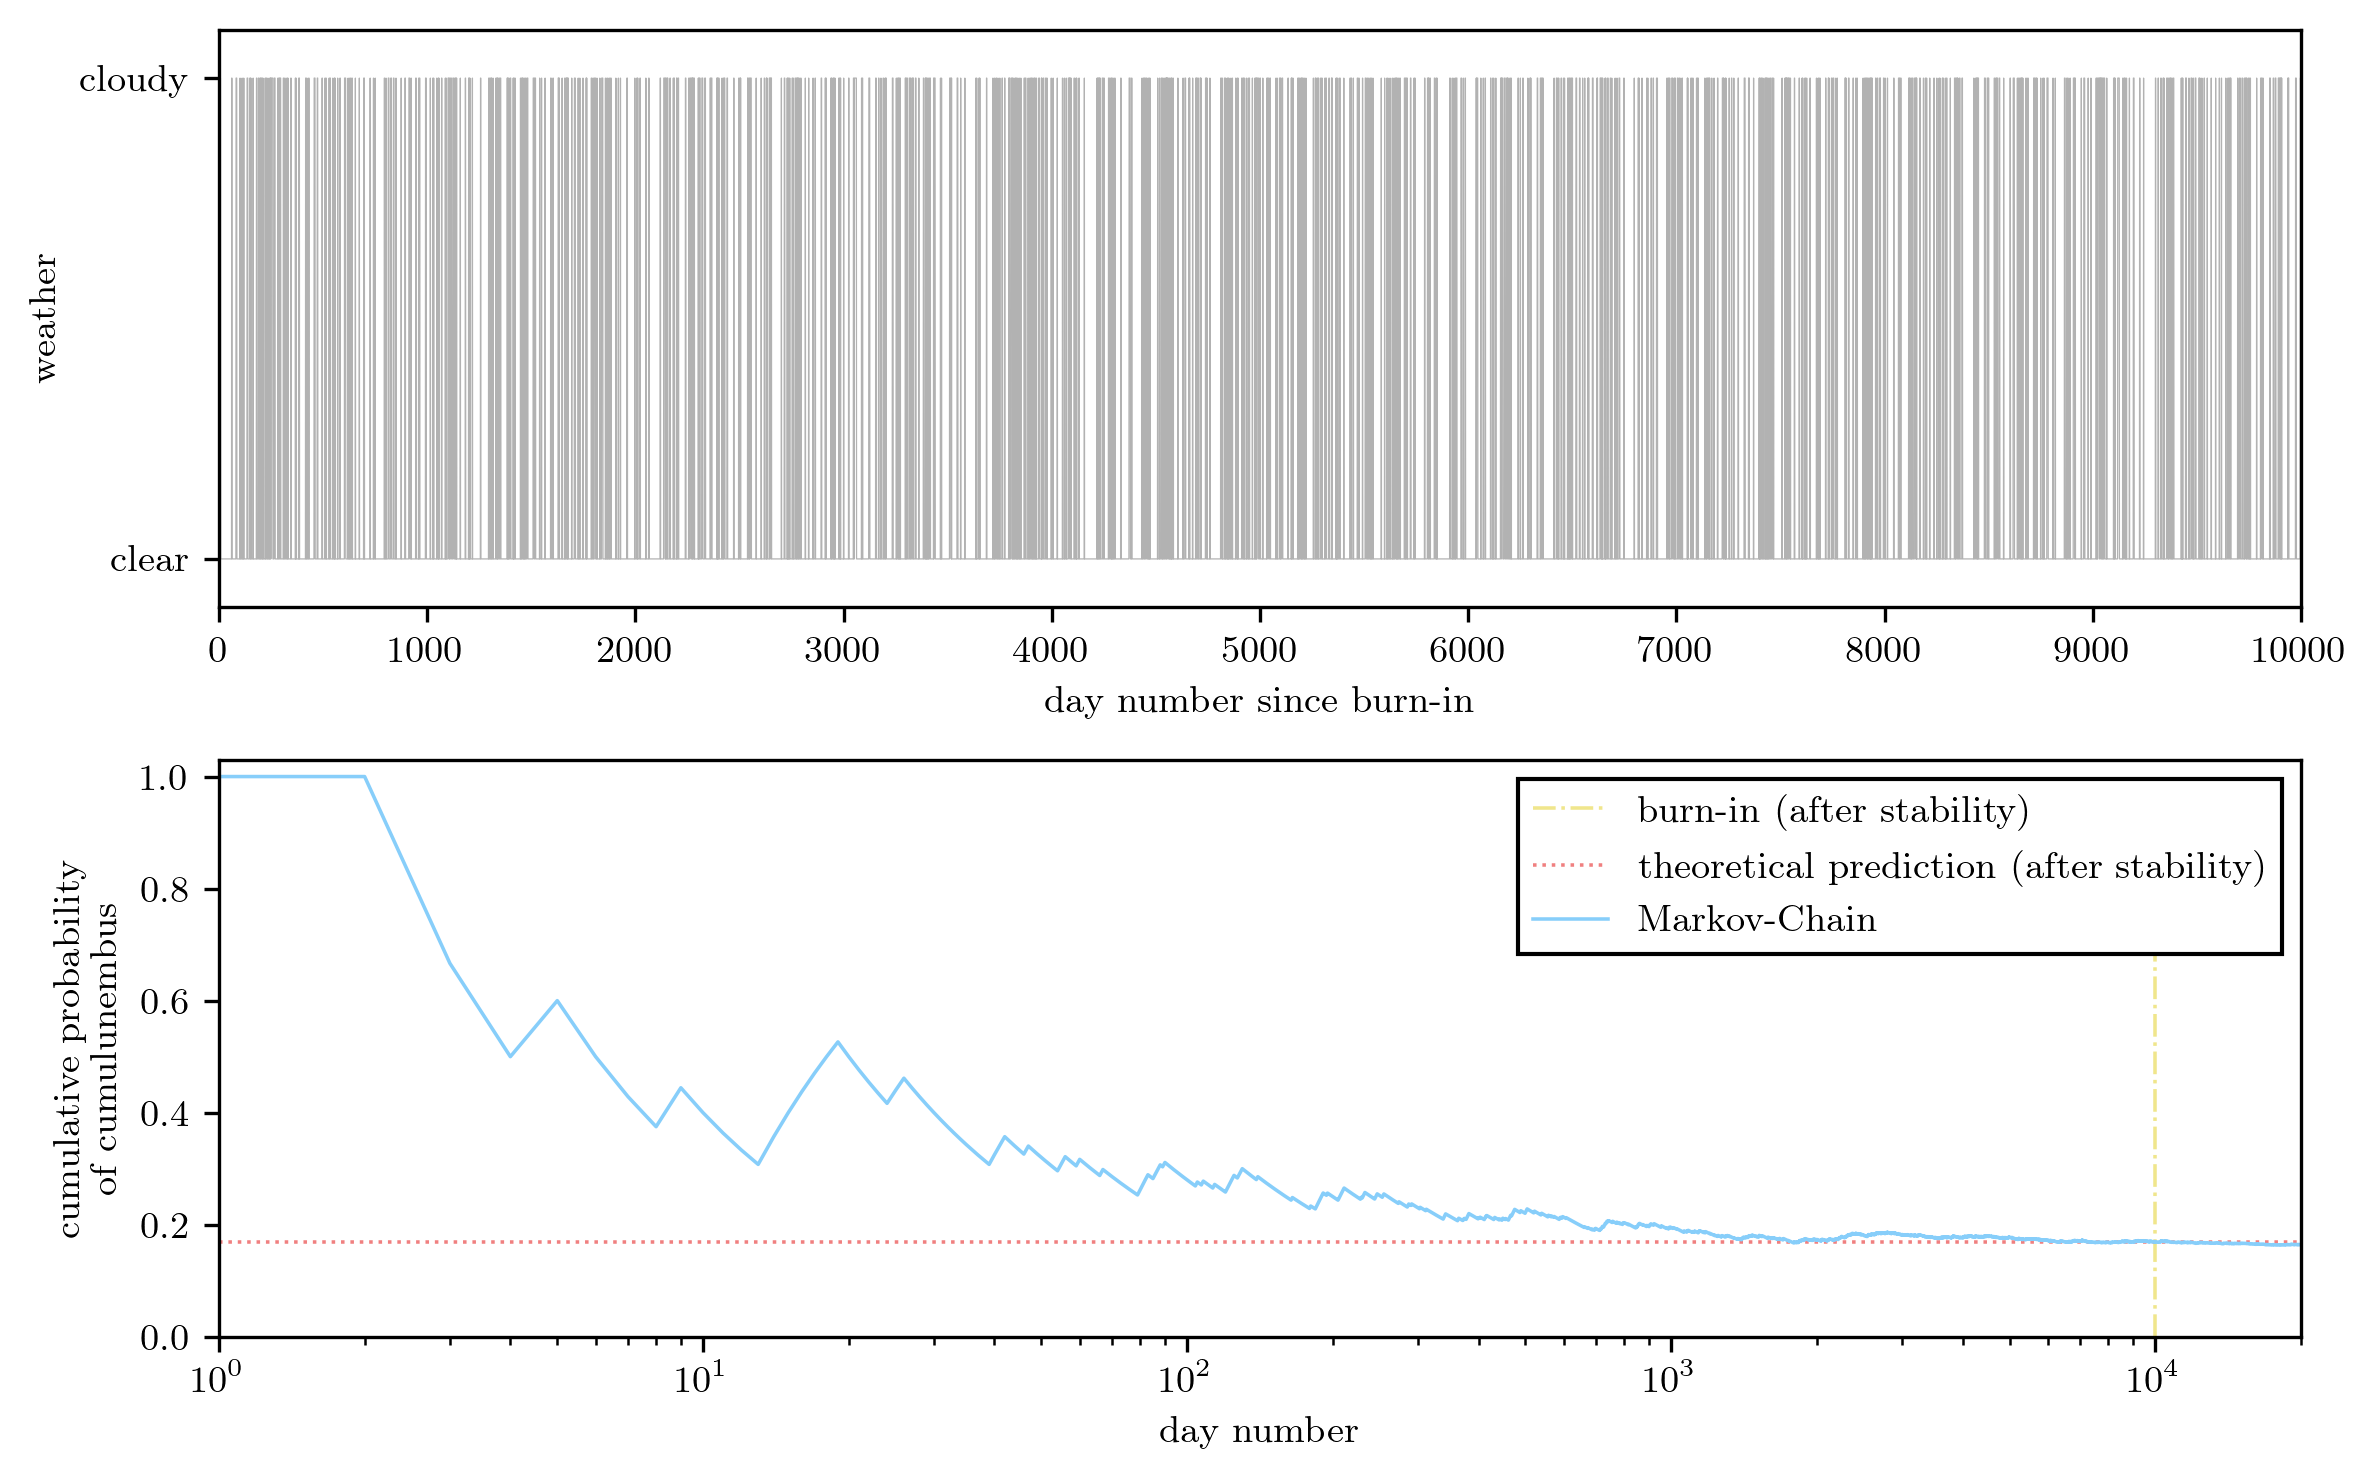

In [95]:
#-------------------------------------------------------------------------
N_days = 20000
N_burn = 10000

# probability of the weather tomorrow given the weather today
p_clear_given_cloud = 0.5
p_cloud_given_cloud = 1 - p_clear_given_cloud
p_clear_given_clear = 0.9
p_cloud_given_clear = 1 - p_clear_given_clear

# the array with the weather on day N: cloudy = 1, clear = 0
weather = np.zeros(N_days)
prob_cloudy_nth_day = np.zeros(N_days)
day_number = np.linspace(start=1,stop=N_days+1,num=N_days)

#-------------------------------------------------------------------------
# Markov-Chain implementation

# start with a cloudy day
weather[0] = 1
prob_cloudy_nth_day[0] = 1

# the Markov Chain
for i in range(N_days-1):
    w = np.random.uniform(0,1)          # extract from a uniform distrib in (0,1)
    if weather[i] == 0:                 # if today it's clear...
        if w > p_clear_given_clear:     # and if we extracted a number in (0.9,1.0)...
            weather[i+1] += 1           # then tomorrow it's cloudy (otherwise, it's clear)
    else:                               # if today it's cloudy instead...
        if w > 0.5:                     # and if we extracted a number in (0.5,1.0)...
            weather[i+1] += 1           # then tomorrow it's cloudy (otherwise, it's clear)
    prob_cloudy_nth_day[i+1] = np.sum(weather) / (i+2)      # update the running prob that it's cloudy


#-------------------------------------------------------------------------
# Plots
        
# the trace plot of cloudy days / all days is just:
fig , ax = plt.subplots(2,1,figsize=(8,5))

ax[0].set_ylim(-0.1,1.1)
ax[0].set_yticks([0,1])
ax[0].set_yticklabels(['clear','cloudy'])
ax[0].set_ylabel('weather')
ax[0].set_xlim(0,N_days-N_burn)
ax[0].set_xticks(np.linspace(0,N_days-N_burn,11))
ax[0].set_xlabel('day number since burn-in')

ax[0].plot(day_number[N_burn:] - N_burn, weather[N_burn:], color='black', lw=0.3, alpha=0.3)

ax[1].set_ylim(0,1.03)
ax[0].set_yticks([0,1])
ax[1].set_ylabel('cumulative probability' + '\n' + 'of cumulunembus')
ax[1].set_xlim(1,N_days)
ax[1].set_xscale('log')
ax[1].set_xlabel('day number')

ax[1].vlines(N_burn, ymin=0, ymax=1, color='khaki', lw=0.85, ls='-.', label='burn-in (after stability)')
ax[1].hlines(0.17, xmin=1, xmax=N_days, color='lightcoral', lw=0.85, ls=':', label='theoretical prediction (after stability)')
ax[1].plot(day_number, prob_cloudy_nth_day, color='lightskyblue', lw=0.85, label='Markov-Chain')

_ = ax[1].legend(loc=1,frameon=True, framealpha=1, fancybox=False, edgecolor='black')

fig.tight_layout()

#-------------------------------------------------------------------------
# do we want to save the figure?
if True:
    if current_pwd[-6:] == 'GitHub':
        fig.savefig('./working/L10_images/L10_Markov_Chain_Weather.pdf', bbox_inches='tight')
    elif current_pwd[-14:] == 'GitHub\working':
        fig.savefig('./L10_images/L10_Markov_Chain_Weather.pdf', bbox_inches='tight')

